In [1]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import scipy.integrate as spint
from scipy.optimize import curve_fit
import csv
import sys
sys.path.insert(1, '/Users/users/costa/Bulk/HC/project1/scripts')
import BayesLineFit_mod as blf

In [19]:
sfrd_path = '../data/allSFRprofs/'
dwarf_list = ['DDO47', 'DDO50', 'DDO52', 'DDO87', 'DDO101', 'DDO126', 'DDO133', 'DDO168', 'NGC2366', 'WLM']
header_list = ["R[kpc]", "Vrot[km/s]", "e_Vrot[km/s]", "Sigma_gas[Msun/kpc2]", "e_Sigma_gas[Msun/kpc2]", "Sigma_SFR[Msun/yr/kpc2]", "e_Sigma_SFR[Msun/yr/kpc2]"]

sfrd_dict = {}

for gal in dwarf_list:
    print(f"Processing galaxy: {gal}")
    # Load SFRD data
    sfrd_file = os.path.join(sfrd_path, f"{gal}_R_Vrot_SigmaGas_SigmaSFR.txt")
    sfrd_data = pd.read_csv(sfrd_file, delim_whitespace=True)
    
    # save data for easy access, in a dictionary, with an array of arrays for each galaxy
    
    sfrd_dict[gal] = {
        "R": sfrd_data["R[kpc]"].values,
        "Vrot": sfrd_data["Vrot[km/s]"].values,
        "e_Vrot": sfrd_data["e_Vrot[km/s]"].values,
        "Sigma_gas": sfrd_data["Sigma_gas[Msun/kpc2]"].values,
        "e_Sigma_gas": sfrd_data["e_Sigma_gas[Msun/kpc2]"].values,
        "Sigma_SFR": sfrd_data["Sigma_SFR[Msun/yr/kpc2]"].values,
        "e_Sigma_SFR": sfrd_data["e_Sigma_SFR[Msun/yr/kpc2]"].values
    }

Processing galaxy: DDO47
Processing galaxy: DDO50
Processing galaxy: DDO52
Processing galaxy: DDO87
Processing galaxy: DDO101
Processing galaxy: DDO126
Processing galaxy: DDO133
Processing galaxy: DDO168
Processing galaxy: NGC2366
Processing galaxy: WLM


In [12]:
# how to read the dictionary:
sfrd_dict['DDO47']['R']  # gives the R array for DDO47

array([0.38, 0.76, 1.13, 1.51, 1.89, 2.27, 2.65, 3.03, 3.4 , 3.78, 4.16,
       4.54, 4.92, 5.29])

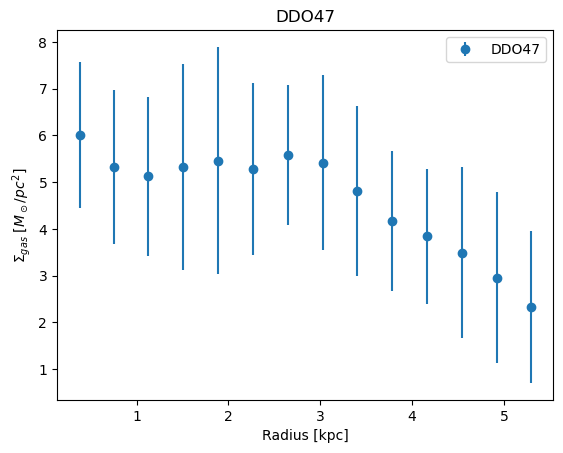

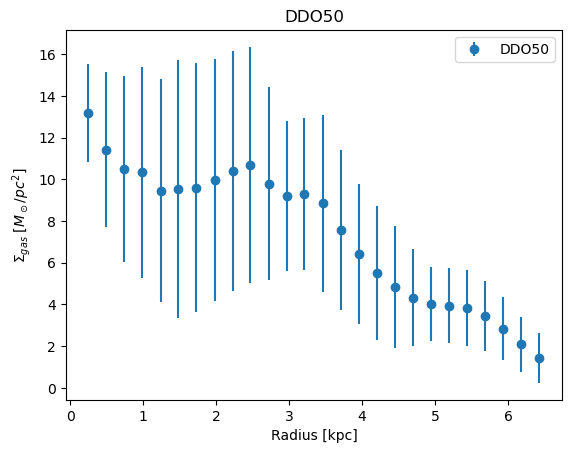

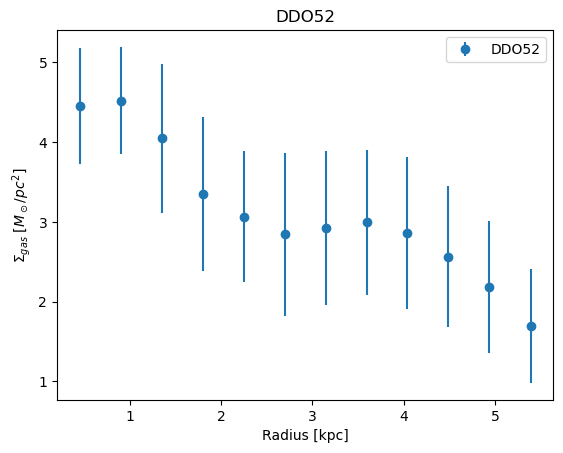

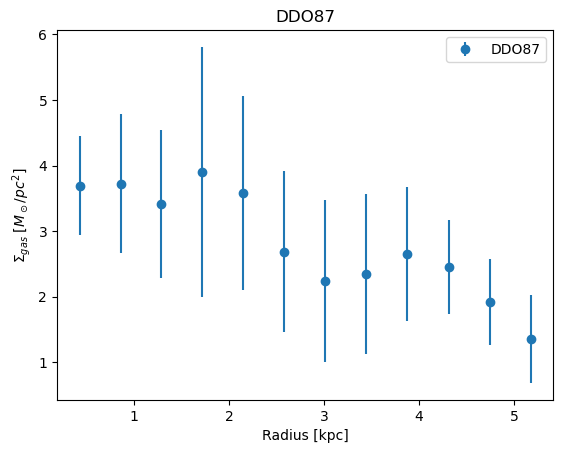

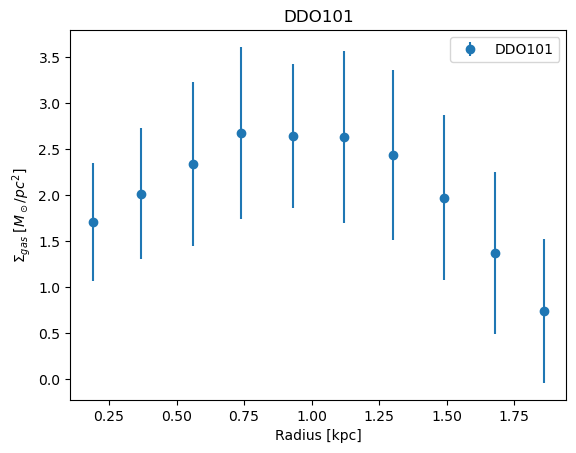

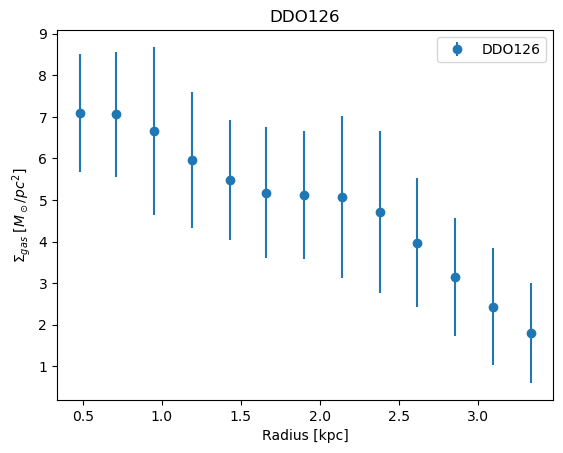

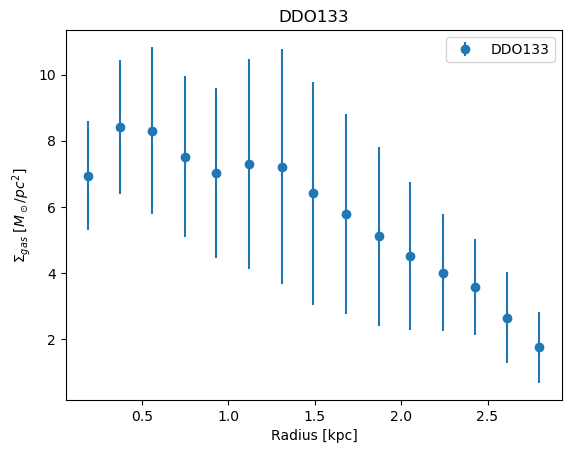

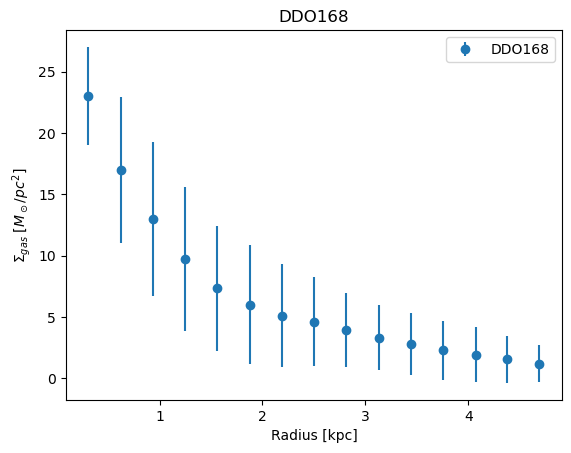

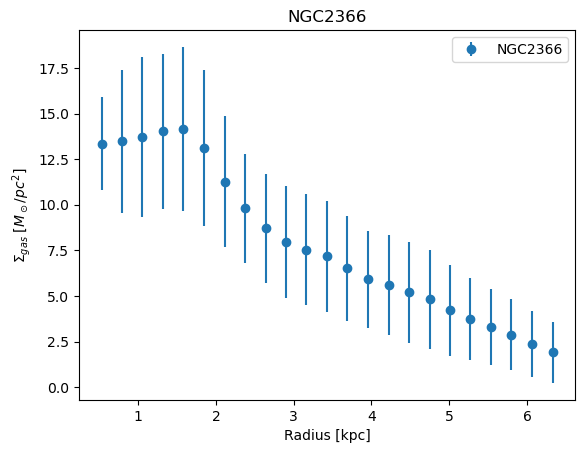

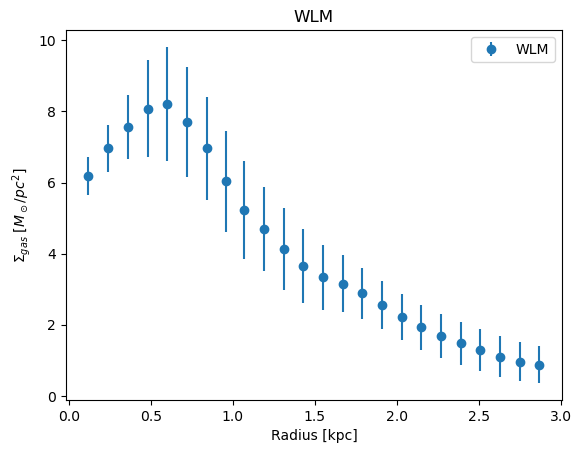

In [ ]:
# for each galaxy, plot Sigma_gas vs R

for gal in dwarf_list:
    R = sfrd_dict[gal]['R']
    Sigma_gas = sfrd_dict[gal]['Sigma_gas']*1e-6  # convert to Msun/pc^2
    e_Sigma_gas = sfrd_dict[gal]['e_Sigma_gas']*1e-6  # convert to Msun/pc^2
    
    plt.errorbar(R, 1.4*Sigma_gas, yerr=1.4*e_Sigma_gas, fmt='o', label=gal)
    plt.xlabel('Radius [kpc]')
    plt.ylabel(r'$\Sigma_{gas}$ [$M_\odot/pc^2$]')
    plt.title(f'{gal}')
    plt.legend()
    plt.show()

In [20]:
massive_file = '/Users/users/costa/Bulk/HC/project1/data/all_gals_Leroy08forHI_Frank16forH2.txt'

cols = ['gal', 'r_l08(kpc)', 'hi_l08(Msun/pc^2)', 'hi_err_l08(Msun/pc^2)', 'h2_f16_at_rl08(Msun/pc^2)', 'h2_err_f16_at_rl08(Msun/pc^2)', 'sfrd_l08(1e-4*Msun/yr/kpc^2)', 'sfrd_err_l08(1e-4*Msun/yr/kpc^2)']

massive_sfrd_data = pd.read_csv(massive_file, sep=r"\s+", header=None, names=cols, comment="#", engine="python", dtype={"gal": "string"})
# print names of galaxies

massive_sfrd_data["gal"] = massive_sfrd_data["gal"].str.strip()
massive_sfrd_gal_names = massive_sfrd_data["gal"].unique().tolist()
print(massive_sfrd_gal_names)

['DDO154', 'IC2574', 'NGC0925', 'NGC2403', 'NGC2841', 'NGC2976', 'NGC3198', 'NGC4736', 'NGC5055', 'NGC6946', 'NGC7331', 'NGC7793']


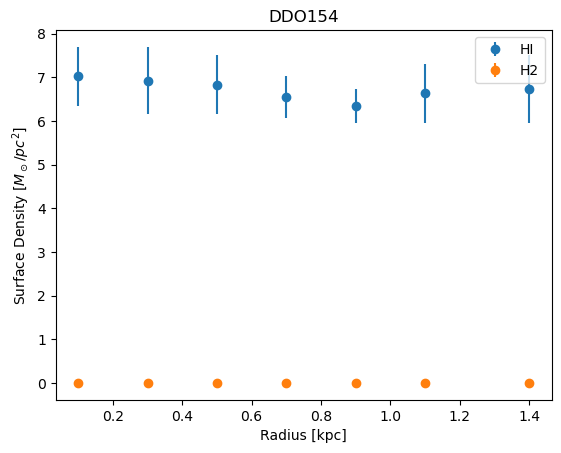

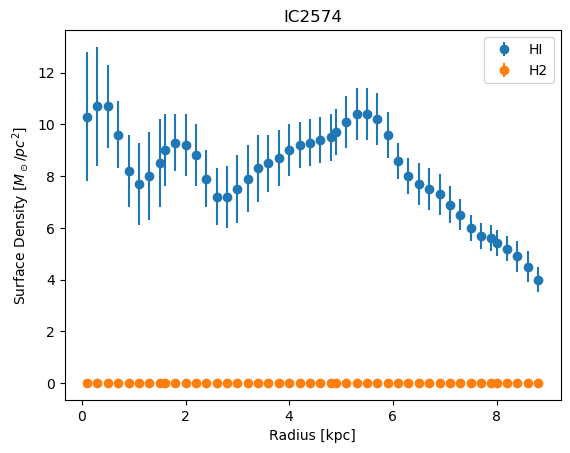

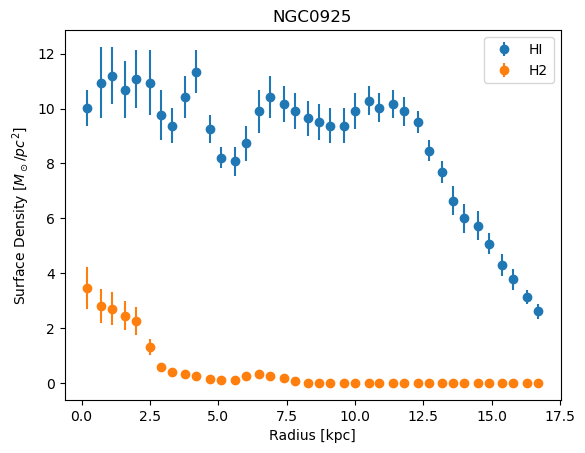

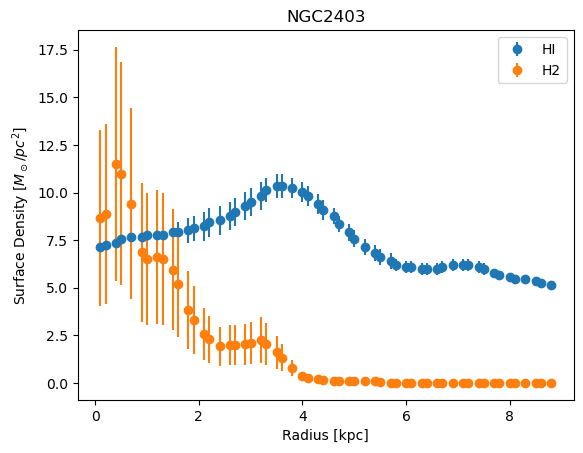

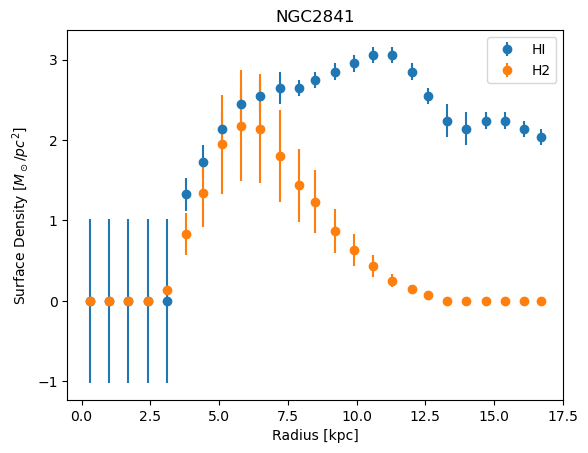

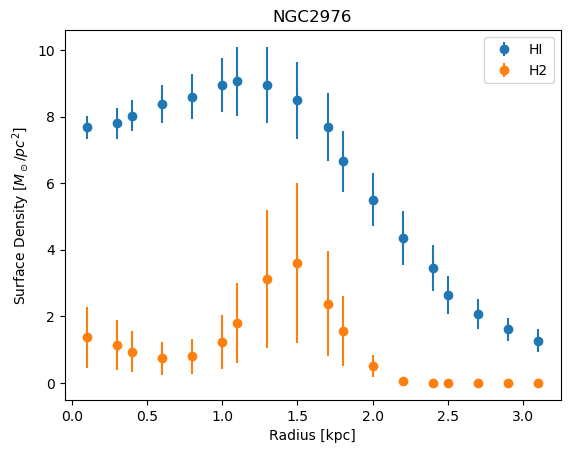

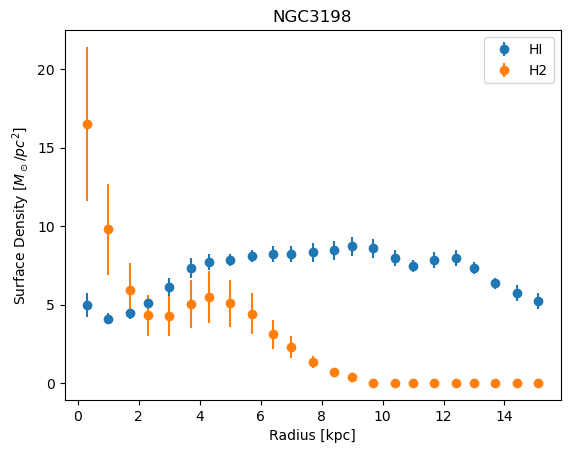

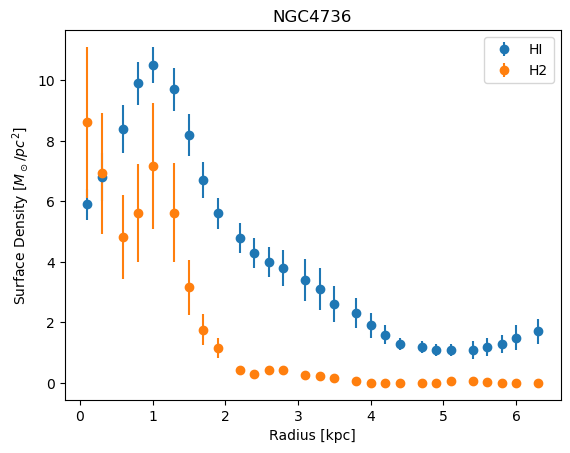

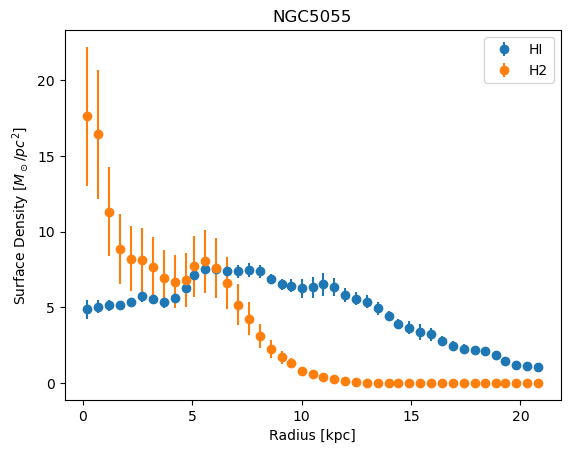

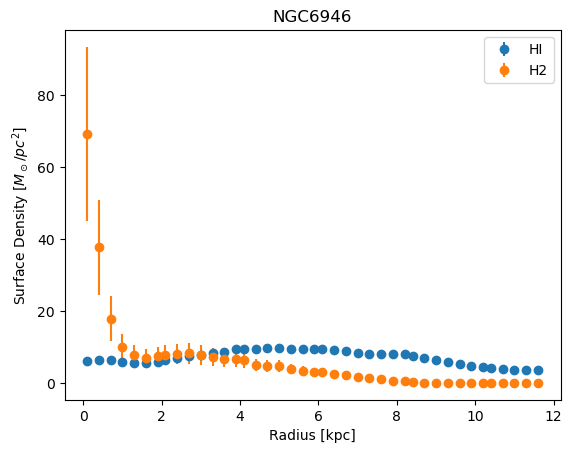

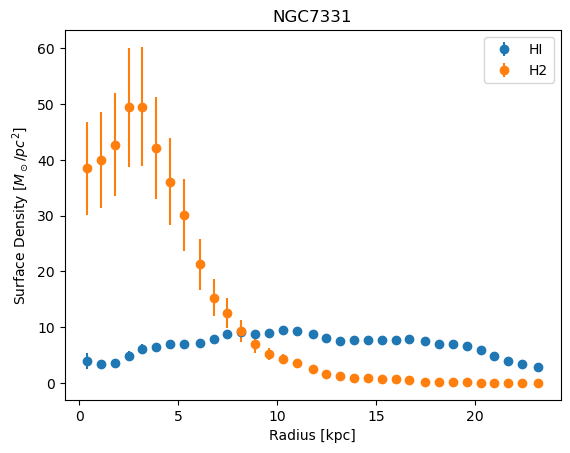

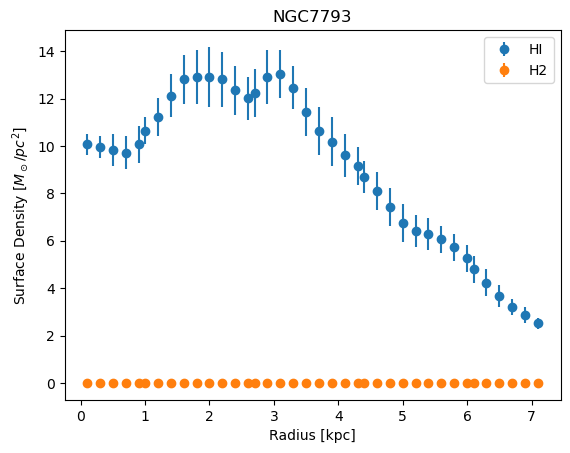

In [26]:
# for each galaxy in massive_sfrd_data, plot HI, H2 vs R (in the same plot, but a different one for each galaxy)

for gal in massive_sfrd_gal_names:
    gal_data = massive_sfrd_data[massive_sfrd_data["gal"] == gal]
    R = gal_data["r_l08(kpc)"].values
    HI = gal_data["hi_l08(Msun/pc^2)"].values
    HI_err = gal_data["hi_err_l08(Msun/pc^2)"].values
    H2 = gal_data["h2_f16_at_rl08(Msun/pc^2)"].values
    H2_err = gal_data["h2_err_f16_at_rl08(Msun/pc^2)"].values
    
    plt.errorbar(R, HI, yerr=HI_err, fmt='o', label='HI')
    plt.errorbar(R, H2, yerr=H2_err, fmt='o', label='H2')
    plt.xlabel('Radius [kpc]')
    plt.ylabel(r'Surface Density [$M_\odot/pc^2$]')
    #plt.yscale('log')
    plt.title(f'{gal}')
    plt.legend()
    plt.show()

Conclusion: Massive galaxies (new file) have He included; dwarfs (old files) do NOT. DDO154 doesn't seem to fully agree with Cecilia's plots.